In [102]:
import numpy as np
import matplotlib.pyplot as plt
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy import constants
def complex_chirp(n_samples, f0, f1, fs, phi0=0):
  """
  Generate a complex chirp signal.

  Args:
    n_samples: Number of samples.
    f0: Start frequency (Hz).
    f1: End frequency (Hz).
    fs: Sampling rate (Hz).
    phi0: Initial phase (radians).

  Returns:
    Complex chirp signal (numpy array).
  """

  # Create the time vector.
  t = np.arange(n_samples) / fs

  # Calculate the instantaneous frequency at each time point.
  f_inst = np.linspace(f0, f1, n_samples)

  # Calculate the phase at each time point.
  phase = 2 * np.pi * np.cumsum(f_inst) * (t[1] - t[0]) + phi0

  # Generate the complex chirp signal.
  chirp = np.exp(1j * phase)

  return chirp

def processSignals(ref, echo, burst_len, num_steps):
    signal_ratio = echo*np.conjugate(ref);
    #signal_ratio = echo/ref
    signal_ratio_reshaped = np.reshape(signal_ratio,[-1,burst_len])
    freq_response = np.mean(signal_ratio_reshaped, axis=1)
    s = freq_response * np.hamming(num_steps)
    s = np.fft.ifft(s)
    range_profile = np.abs(s)
    min_v = np.min(range_profile)
    max_v = np.max(range_profile)
    range_profile = (range_profile - min_v)/(max_v-min_v)
    return range_profile

def B_scan(dir, prefix, burst_len, num_steps):
    supposed_size = burst_len*num_steps
    s_list = []
    for i in range(14):
        #print(i)
        fileName_rx = dir + prefix + '_rx_' + str(i) + '.dat'
        fileName_ref = dir + prefix + '_ref_' + str(i) + '.dat'
        
        ref_samples = np.fromfile(fileName_ref, np.complex64)
        N = supposed_size - ref_samples.size
        #print(ref_samples.size,N)
        if N>=0:
            ref_samples = np.pad(ref_samples,(0,N),'constant')
        else:
            ref_samples = ref_samples[0:supposed_size]
        
        rx_samples = np.fromfile(fileName_rx, np.complex64)  
        N = supposed_size - rx_samples.size
        #print(rx_samples.size,N)
        if N>=0:
            rx_samples = np.pad(rx_samples,(0,N),'constant')
        else:
            rx_samples = rx_samples[0:supposed_size]
        
        f,s = processSignals(ref_samples, rx_samples, burst_len, num_steps)
        s_list.append(s)
    return np.stack(s_list, axis=0)   

def normaliseSignals(input_sammples,burst_len,num_steps):
    samples = np.reshape(input_sammples,[num_steps,-1])
    print(samples.shape)
    samples_real = np.real(samples)
    samples_imag = np.imag(samples)
    max_val = np.max(samples_real,axis=1)
    min_val = np.min(samples_real,axis=1)
    samples_real_normalised = 2*(np.transpose(samples_real)-min_val)/(max_val-min_val)-1
    samples_real_normalised = np.transpose(samples_real_normalised).ravel()
    max_val = np.max(samples_imag,axis=1)
    min_val = np.min(samples_imag,axis=1)
    samples_imag_normalised = 2*(np.transpose(samples_imag)-min_val)/(max_val-min_val)-1
    samples_imag_normalised = np.transpose(samples_imag_normalised).ravel()
    return samples_real_normalised+1j*samples_imag_normalised

from pylab import *
def fix_iq_imbalance(x):
    # remove DC and save input power
    z = x - mean(x)
    p_in = var(z)

    # scale Q to have unit amplitude (remember we're assuming a single input tone)
    Q_amp = sqrt(2*mean(x.imag**2))
    z /= Q_amp

    I, Q = z.real, z.imag

    alpha_est = sqrt(2*mean(I**2))
    sin_phi_est = (2/alpha_est)*mean(I*Q)
    cos_phi_est = sqrt(1 - sin_phi_est**2)

    I_new_p = (1/alpha_est)*I
    Q_new_p = (-sin_phi_est/alpha_est)*I + Q

    y = (I_new_p + 1j*Q_new_p)/cos_phi_est

    #print ('phase error:', arccos(cos_phi_est)*360/2/pi, 'degrees')
    #print ('amplitude error:', 20*log10(alpha_est), 'dB')

    return y*sqrt(p_in/var(y))

def plot_chirp_frequency(chirp, fs):
  """
  Plots the instantaneous frequency of a chirp signal over time.

  Args:
    chirp: Complex chirp signal (numpy array).
    fs: Sampling rate (Hz).
  """

  # Calculate the instantaneous frequency using the derivative of the phase.
  phase = np.unwrap(np.angle(chirp))
  inst_freq = fs * np.diff(phase) / (2 * np.pi)

  # Create the time vector for the instantaneous frequency.
  t = np.arange(len(inst_freq)) / fs

  # Plot the instantaneous frequency.
  plt.plot(t, inst_freq)
  plt.xlabel("Time (s)")
  plt.ylabel("Instantaneous Frequency (Hz)")
  plt.title("Chirp Frequency Over Time")
  plt.grid(True)
  plt.show()

In [103]:
def process_raw_samples(fileName_rx, fileName_ref, burst_len, num_steps,resampling_factor=1):
    ref_samples = np.fromfile(fileName_ref, np.complex64)
    rx_samples = np.fromfile(fileName_rx, np.complex64) 
    print("ref_samples size: ", ref_samples.size)
    print("rx_samples size: ", rx_samples.size)

    #normalise samples
    # ref_samples = normaliseSignals(ref_samples,burst_len,num_steps)
    # rx_samples = normaliseSignals(rx_samples,burst_len,num_steps)

    #reshape samples into busrt
    rx_samples_reshaped = rx_samples.reshape([num_steps,-1])
    #rx_samples_reshaped = signal.resample(rx_samples_reshaped,int(burst_len*resampling_factor),axis=1)
    rx_samples_reshaped = signal.resample_poly(rx_samples_reshaped,resampling_factor,1,axis=1)
    ref_samples_reshaped = ref_samples.reshape([num_steps,-1])
    #ref_samples_reshaped = signal.resample(ref_samples_reshaped,int(burst_len*resampling_factor),axis=1)
    ref_samples_reshaped = signal.resample_poly(ref_samples_reshaped,resampling_factor,1,axis=1)

    #drop noisy samples
    # rx_samples_reshaped = rx_samples_reshaped[:,100:100+int(burst_len/2)]
    # ref_samples_reshaped = ref_samples_reshaped[:,100:100+int(burst_len/2)]

    return rx_samples_reshaped, ref_samples_reshaped
    
def signal_processing_multiply_conjugate(echo, ref, burst_len, num_steps):
    signal_ratio = echo*np.conjugate(ref);
    #signal_ratio = echo/ref
    signal_ratio_reshaped = np.reshape(signal_ratio,[-1,burst_len])
    freq_response = np.mean(signal_ratio_reshaped, axis=1)
    s = freq_response * np.hamming(num_steps)
    s = np.fft.ifft(s)
    range_profile = np.abs(s)
    min_v = np.min(range_profile)
    max_v = np.max(range_profile)
    range_profile = (range_profile - min_v)/(max_v-min_v)
    return range_profile
    
def signal_processing_matched_filter_1(rx_samples_reshaped, ref_samples_reshaped, burst_len, num_steps):
    signal_matched_filtered = []
    ch_response = []
    for i in range(num_steps):
        output = signal.correlate(rx_samples_reshaped[i], ref_samples_reshaped[i], mode='same')
        signal_matched_filtered.append(output)
        index = burst_len-1
        ch_response.append(output[index])
    signal_matched_filtered = np.array(signal_matched_filtered)
    ch_response = np.array(ch_response)
    return ch_response, signal_matched_filtered

def signal_processing_matched_filter_2(rx_samples_reshaped, ref_samples_reshaped, burst_len, num_steps):
    signal_matched_filtered = []
    ch_response = []
    for i in range(num_steps):
        output = signal.correlate(rx_samples_reshaped[i], ref_samples_reshaped[i], mode='same')
        signal_matched_filtered.append(output)
        index = np.argmax(np.abs(output))
        ch_response.append(output[index])
    signal_matched_filtered = np.array(signal_matched_filtered)
    ch_response = np.array(ch_response)
    return ch_response, signal_matched_filtered

def signal_processing_matched_filter_fft(rx_samples_reshaped, ref_samples_reshaped, burst_len, num_steps):
    signal_matched_filtered = []
    ch_response = []
    for i in range(num_steps):
        #output = np.fft.fft(rx_samples_reshaped[i])*np.fft.fft(np.conj(np.flip(ref_samples_reshaped[i])))
        output = np.fft.fft(rx_samples_reshaped[i])*np.fft.fft(np.conj(np.flip(ref_samples_reshaped[i])))
        #output = np.fft.fft(rx_samples_reshaped[i])*np.conj(np.fft.fft(ref_samples_reshaped[i]))
        signal_matched_filtered.append(output)
        index = np.argmax(np.abs(output))
        ch_response.append(output[index])
    signal_matched_filtered = np.array(signal_matched_filtered)
    ch_response = np.array(ch_response)
    return ch_response, signal_matched_filtered

def extract_rangeProfile(ch_response, num_steps):
    s = np.hamming(num_steps)*ch_response
    #s_mf = output_f
    s = np.fft.ifft(s)
    range_profile = np.abs(s)
    min_v = np.min(range_profile)
    max_v = np.max(range_profile)
    range_profile = (range_profile - min_v)/(max_v-min_v)
    return range_profile

ref_samples size:  98304
rx_samples size:  98304


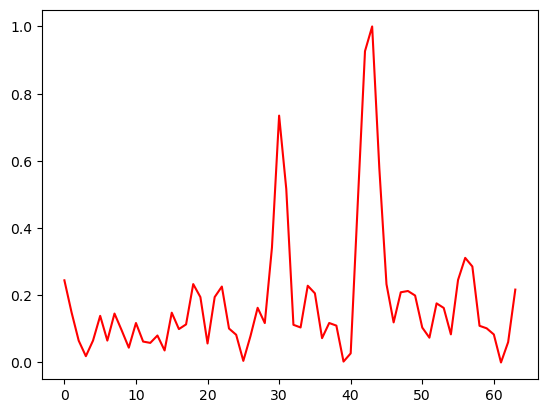

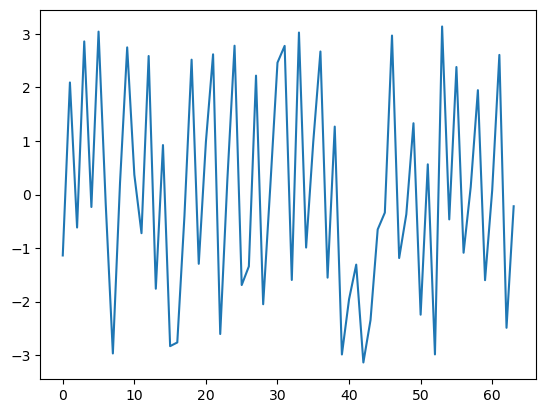

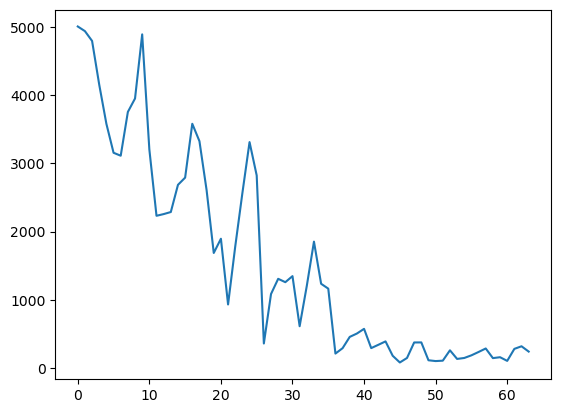

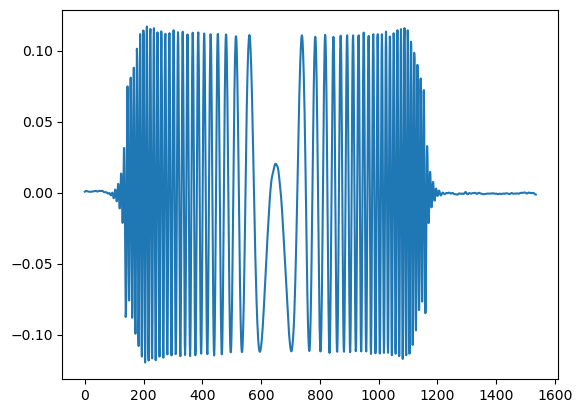

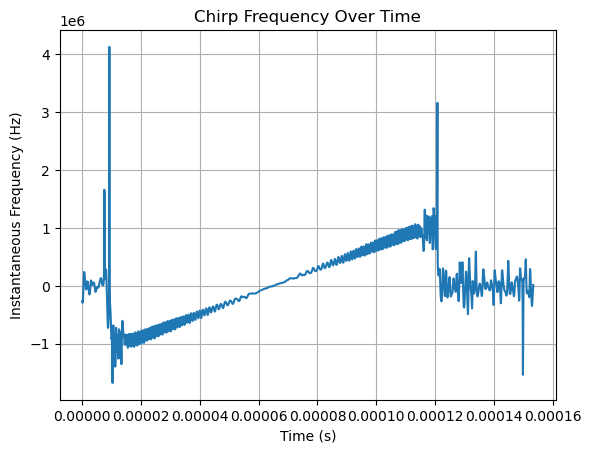

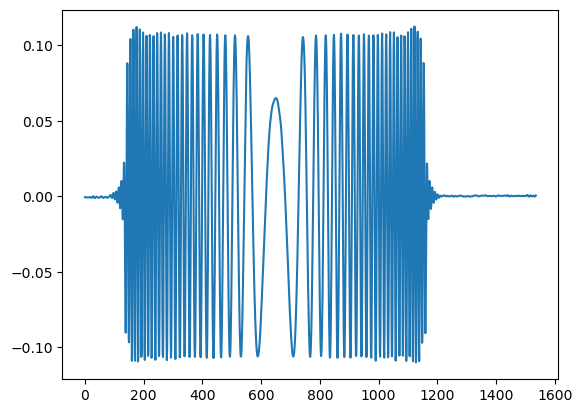

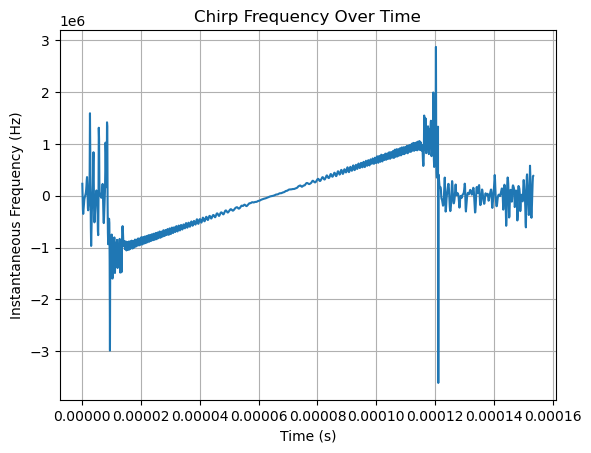

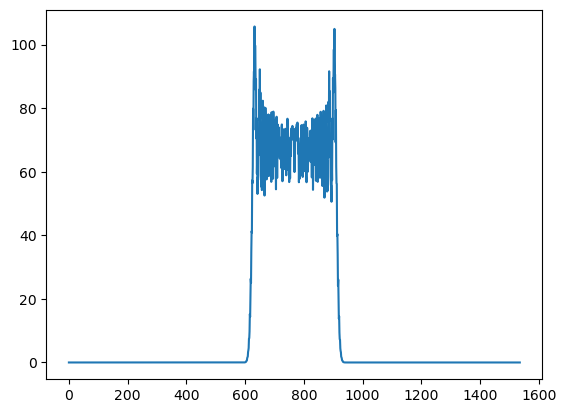

In [108]:
burst_len = 1024+512
num_steps = 64
supposed_size = burst_len*num_steps
dir = '../gui/'
prefix = 'chirp'
i=5
fileName_rx = dir + prefix + '_rx_' + str(i) + '.dat'
fileName_ref = dir + prefix + '_ref_' + str(i) + '.dat'
initial_offset = 80
rx_samples_reshaped, ref_samples_reshaped = process_raw_samples(fileName_rx, fileName_ref, burst_len, num_steps)
#ref_samples_reshaped = ref_samples_reshaped[:,initial_offset:initial_offset+1024]
ch_response, signal_matched_filtered = signal_processing_matched_filter_fft(rx_samples_reshaped, ref_samples_reshaped, burst_len, num_steps)
range_profile_chirp = extract_rangeProfile(ch_response, num_steps)
plt.plot(np.abs(range_profile_chirp),color='red')
plt.figure()
plt.plot(np.angle(ch_response))
plt.figure()
plt.plot(np.abs(ch_response))

index = 60
plt.figure()
plt.plot(np.real(rx_samples_reshaped[index]))
plt.figure()
plot_chirp_frequency(rx_samples_reshaped[index],10e6)

plt.figure()
plt.plot(np.real(ref_samples_reshaped[index]))
plt.figure()
plot_chirp_frequency(ref_samples_reshaped[index],10e6)

plt.figure()
plt.plot(np.abs(np.fft.fftshift(signal_matched_filtered[index])))

In [52]:
rx_samples_reshaped.shape

(64, 12288)

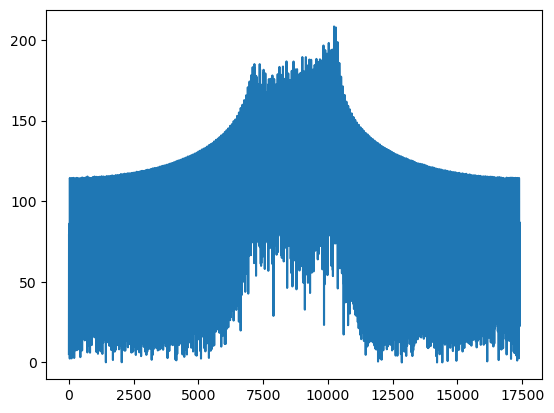

In [40]:
range_p = np.fft.fftshift(np.fft.fft(final_result_ct))
plt.plot(10*log10(np.abs(range_p))**2)

ref_samples size:  65536
rx_samples size:  65536


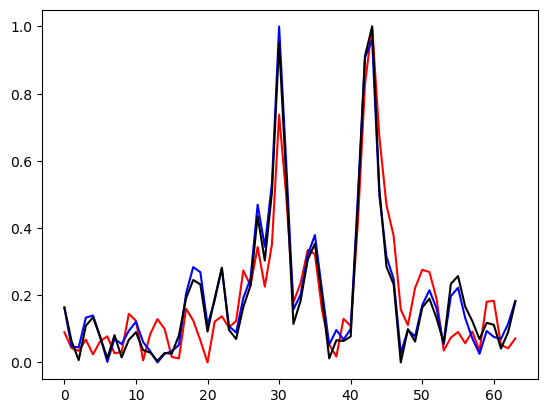

In [97]:
# range_profile = signal_processing_multiply_conjugate(rx_samples_reshaped.flatten(), ref_samples_reshaped.flatten(), burst_len, num_steps)
# plt.figure()
# plt.plot(np.abs(range_profile), 'blue')

# aChirp = complex_chirp(512,-2.5e6,2.5e6,20e6,0)
# plot_chirp_frequency(aChirp,20e6)
# ref_samples_reshaped = []
# for i in range(num_steps):
#     ref_samples_reshaped.append(aChirp)
# ref_samples_reshaped = np.array(ref_samples_reshaped)
# ref_samples_reshaped.shape

burst_len = 1024
num_steps = 64
supposed_size = burst_len*num_steps
dir = '../gui/'
prefix = 'scan'
i=1
fileName_rx = dir + prefix + '_rx_' + str(i) + '.dat'
fileName_ref = dir + prefix + '_ref_' + str(i) + '.dat'

rx_samples_reshaped, ref_samples_reshaped = process_raw_samples(fileName_rx, fileName_ref, burst_len, num_steps,8)

ch_response, signal_matched_filtered = signal_processing_matched_filter_1(rx_samples_reshaped, ref_samples_reshaped, burst_len, num_steps)
range_profile_scan_mf = extract_rangeProfile(ch_response, num_steps)

range_profile_scan_mc = signal_processing_multiply_conjugate(rx_samples_reshaped.flatten(),ref_samples_reshaped.flatten(),burst_len*8, num_steps)

plt.plot(np.abs(range_profile_chirp),color='red')
plt.plot(np.abs(range_profile_scan_mf),color = 'blue')
plt.plot(np.abs(range_profile_scan_mc),color = 'black')

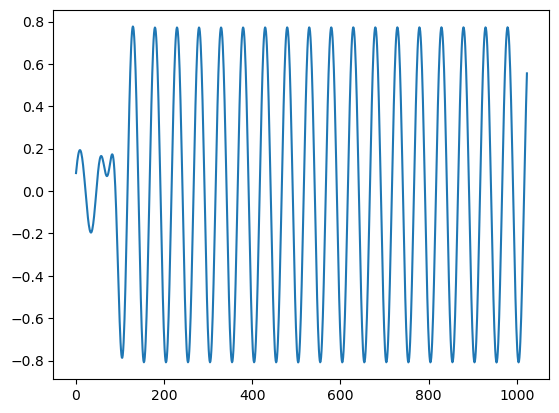

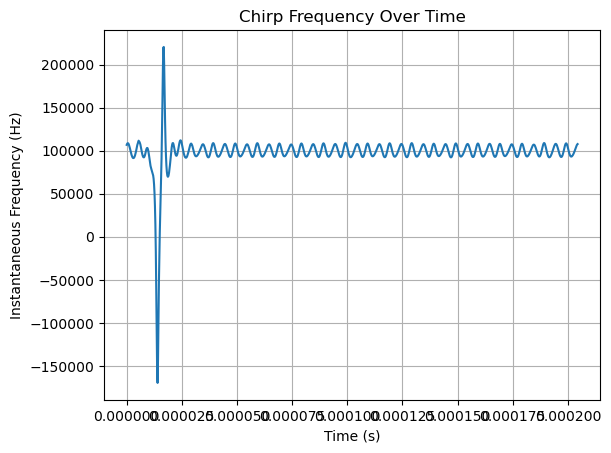

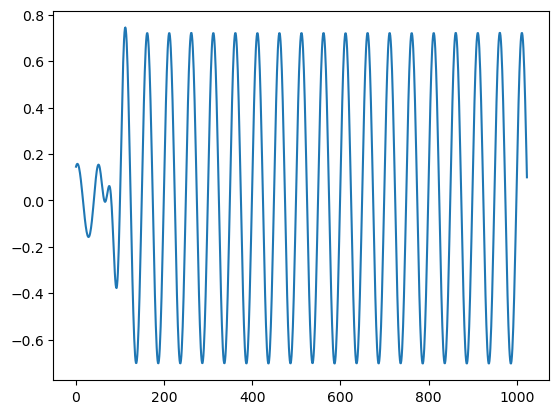

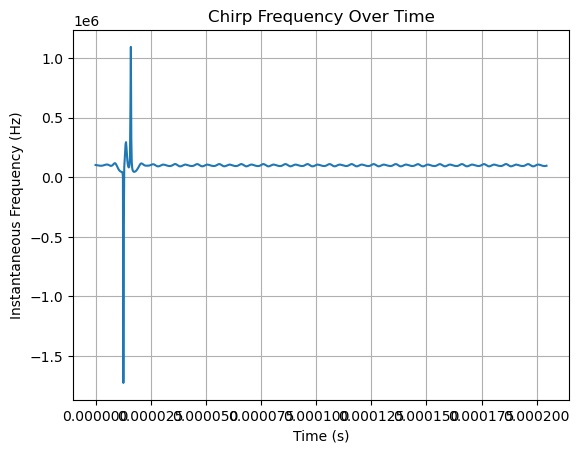

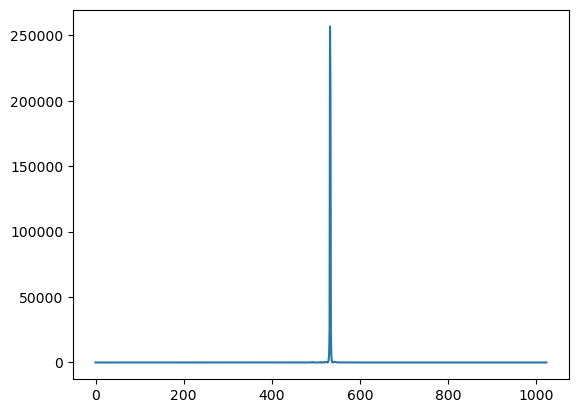

In [20]:
index = 0
plt.plot(np.real(rx_samples_reshaped[index]))
plt.figure()
plot_chirp_frequency(rx_samples_reshaped[index],5e6)

plt.figure()
plt.plot(np.real(ref_samples_reshaped[index]))
plt.figure()
plot_chirp_frequency(ref_samples_reshaped[index],5e6)

plt.figure()
plt.plot(np.abs(np.fft.fftshift(signal_matched_filtered[index])))

In [46]:
burst_len = 1024
num_steps = 64
supposed_size = burst_len*num_steps
dir = '../gui/'
prefix = 'chirp_2'
i=0
fileName_rx = dir + prefix + '_rx_' + str(i) + '.dat'
fileName_ref = dir + prefix + '_ref_' + str(i) + '.dat'
ref_samples = np.fromfile(fileName_ref, np.complex64)
N = supposed_size - ref_samples.size
print(ref_samples.size,N)
if N>=0:
    ref_samples = np.pad(ref_samples,(0,N),'constant')
else:
    ref_samples = ref_samples[0:supposed_size]

rx_samples = np.fromfile(fileName_rx, np.complex64)  
N = supposed_size - rx_samples.size
print(rx_samples.size,N)
if N>=0:
    rx_samples = np.pad(rx_samples,(0,N),'constant')
else:
    rx_samples = rx_samples[0:supposed_size]

ref_complex_normalised = normaliseSignals(ref_samples,burst_len,num_steps)
rx_complex_normalised = normaliseSignals(rx_samples,burst_len,num_steps)

rx_samples_reshaped = rx_samples.reshape([num_steps,-1])
ref_samples_reshaped = ref_samples.reshape([num_steps,-1])
#ref_samples_reshaped = ref.reshape([num_steps,-1])
rx_samples_reshaped = rx_samples_reshaped[:,256:256+512]
ref_samples_reshaped = ref_samples_reshaped[:,256:256+512]
rx_samples = rx_samples_reshaped.flatten()
ref_samples = ref_samples_reshaped.flatten()



signal_matched_filtered = []
output_f = []
#matched_filters = np.conj(np.flip(ref,axis=1))
#matched_filters = np.conj(ref_samples_reshaped,axis=1)
#print(matched_filters.shape[0])
for i in range(num_steps):
    output = np.fft.fft(fix_iq_imbalance(rx_samples_reshaped[i]))*np.fft.fft(np.conj(np.flip(fix_iq_imbalance(ref_samples_reshaped[i]))))
    #matched_filter = np.conj(np.flip(fix_iq_imbalance(ref_samples_reshaped[i])))
    #output = np.convolve(fix_iq_imbalance(rx_samples_reshaped[i]),matched_filter)
    #output = signal.correlate(fix_iq_imbalance(rx_samples_reshaped[i]), fix_iq_imbalance(ref_samples_reshaped[i]), mode='same')
    #output = signal.correlate(rx_samples_reshaped[i], ref_samples_reshaped[i], mode='same')
    # signal_matched_filtered.append(output)
    # #f = np.fft.fft(output)
    f = output
    index = np.argmax(np.abs(f))
    output_f.append(f[index])
    #output_f.append(output)
signal_matched_filtered = np.array(signal_matched_filtered)
output_f = np.array(output_f)
output_f.shape

s_mf = np.hamming(num_steps)*output_f
#s_mf = output_f
s_mf = np.fft.ifft(s_mf)
range_profile_mf = np.abs(s_mf)
min_v = np.min(range_profile_mf)
max_v = np.max(range_profile_mf)
range_profile_mf = (range_profile_mf - min_v)/(max_v-min_v)
# plt.plot(range_profile,color='red')
# plt.figure()
# plt.plot(np.angle(output_f))
plt.figure()
#plt.plot(range_profile,color='red')
plt.plot(range_profile_mf,color='blue')
plt.figure()
#plt.plot(np.angle(f),color = 'red')
plt.plot(np.angle(output_f),color='blue')
plt.figure()
plt.plot(np.abs(output_f))

FileNotFoundError: [Errno 2] No such file or directory: '../gui/chirp_2_ref_0.dat'

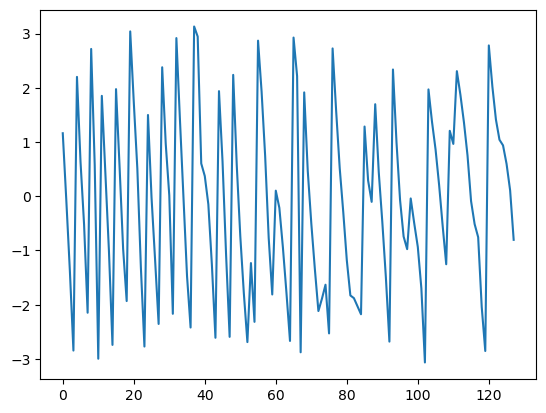

In [11]:
plt.plot(np.angle(output_f))

In [164]:
num_steps = 64
df = 30e6
print(constants.c/(2*num_steps*df))
print(constants.c/(2*df))

0.07807095260416666
4.996540966666666


In [161]:
0.058553214453125*256

14.9896229